In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl
import seaborn as sns
import h5py
import time
import scipy.sparse as sp
import yaml
import gc
from matplotlib import gridspec

import rmm
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

import cuml
from cuml.decomposition import PCA

import psutil
import torch
from datetime import datetime

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

sc.settings.verbosity = 3

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
start = time.perf_counter()

fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/processed/sample_1_adata.h5ad"
adata = sc.read_h5ad(fpath)
adata.obsm['X_umap'] = adata.obsm['X_umap_X_scANVI'].copy()

sc.logging.print_memory_usage() # Log memory at the end

print(f"Total time: {time.perf_counter() - start:.2f} seconds")

adata # Return/output adata

Memory usage: current 48.81 GB, difference +48.81 GB
Total time: 56.58 seconds


/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 1125041 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette

# Filter basename

In [3]:
%%time
keep = [
    'fibroblasts',
    'endothelial_cells',
    'hematopoietic_progenitors',
    'hsc',
]

adata = adata[adata.obs['basename'].isin(keep), :].copy()
adata

CPU times: user 14.3 s, sys: 26.9 s, total: 41.2 s
Wall time: 41.4 s


/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 509808 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette'

# Sample

In [4]:
fraction = 0.10
adata = adata.copy()
adata = sc.pp.subsample(adata, fraction=fraction, copy=True)

sc.pp.filter_cells(adata, min_counts=300)
sc.pp.filter_genes(adata, min_counts=100)

print(f"Filtered: {adata.shape=}")
adata

filtered out 20 cells that have less than 300 counts
filtered out 30829 genes that are detected in less than 100 counts
Filtered: adata.shape=(50960, 21335)


AnnData object with n_obs × n_vars = 50960 × 21335
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette',

[2025-05-07 10:52:29.412] [CUML] [debug] n_neighbors=750
[2025-05-07 10:52:29.412] [CUML] [debug] Calling knn graph run
[2025-05-07 10:52:29.412] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-07 10:52:30.202] [CUML] [debug] Done. Calling remove zeros


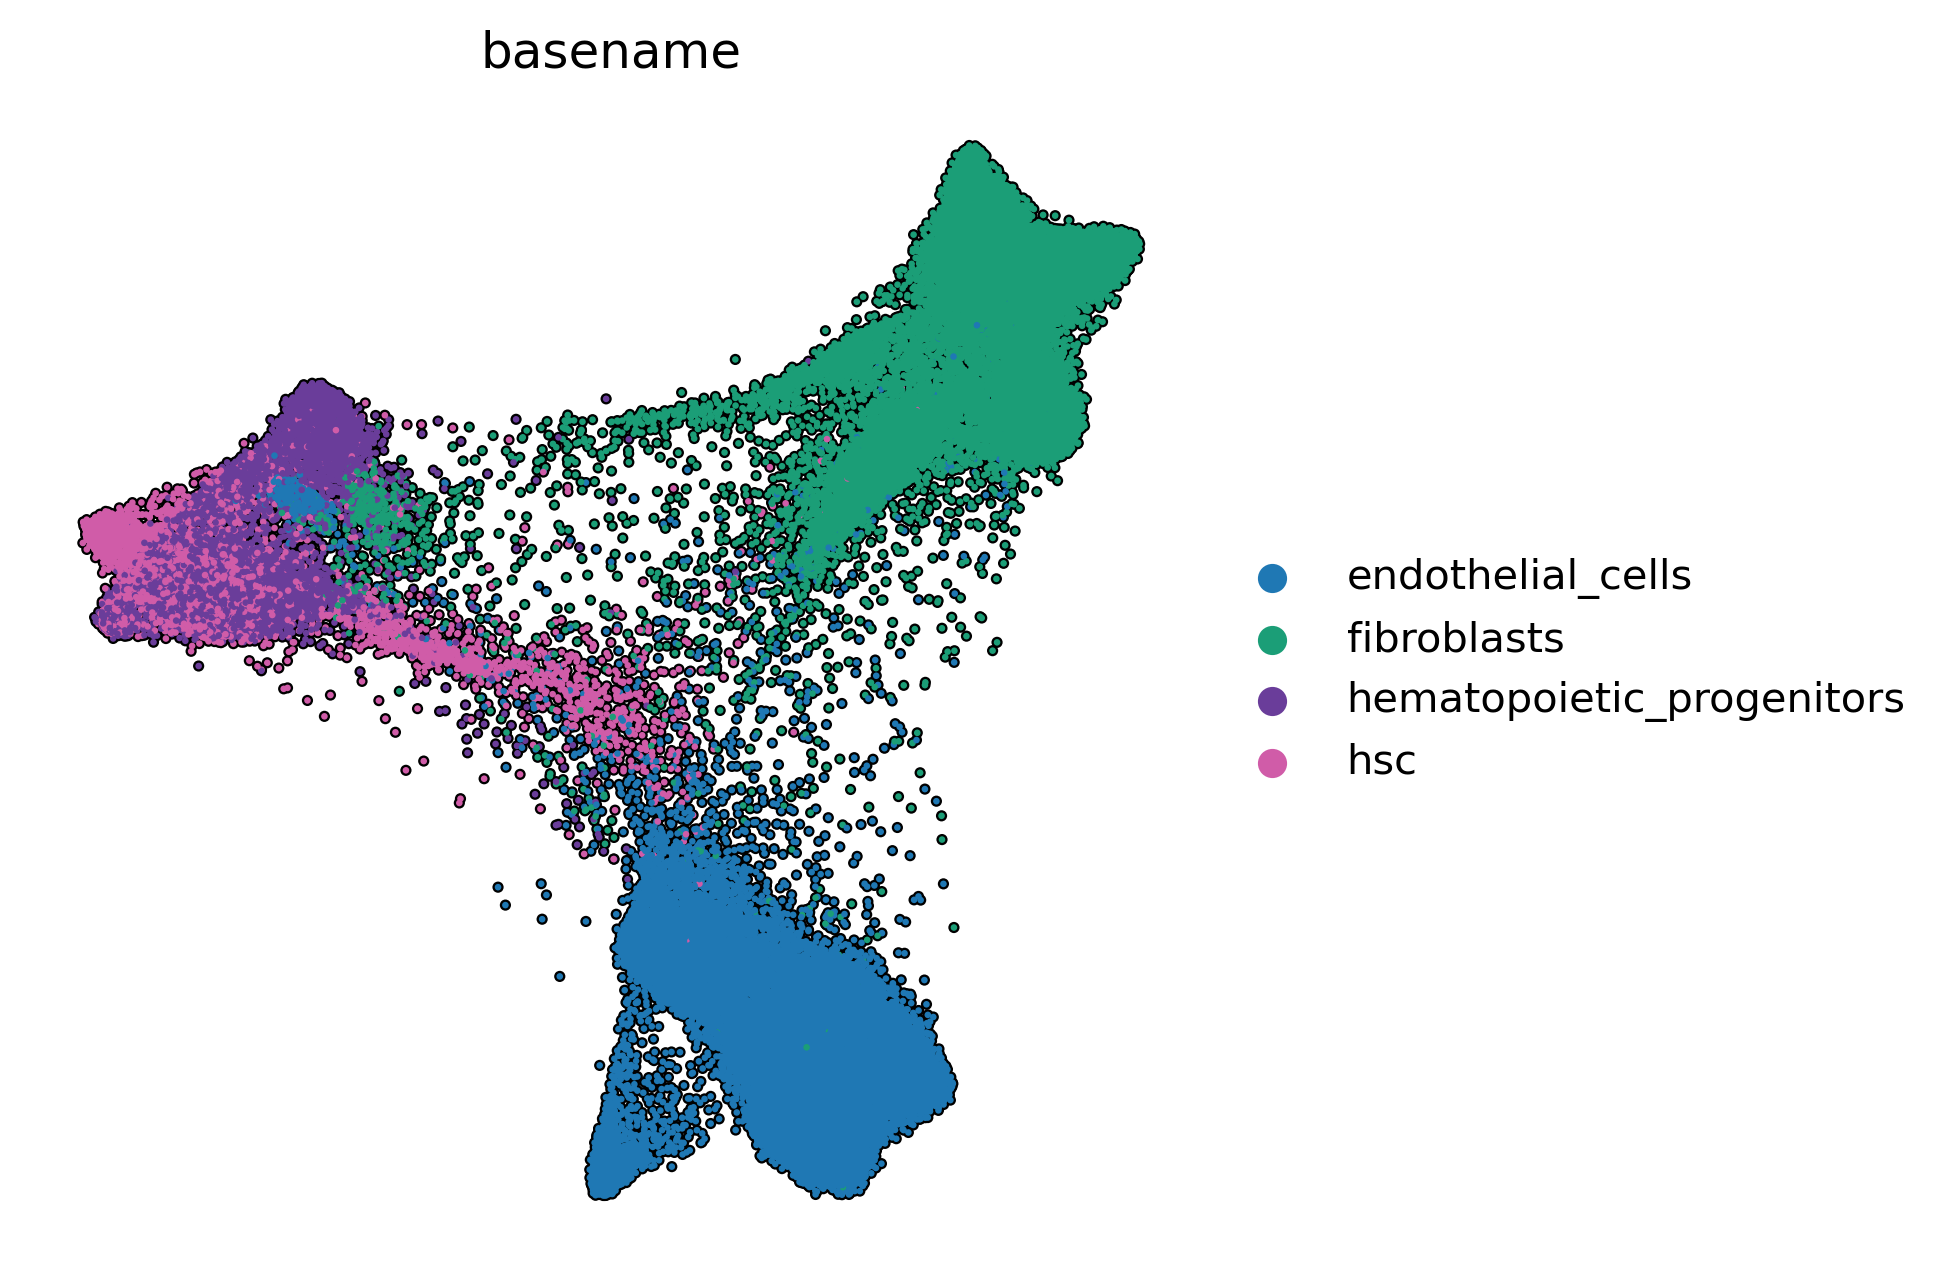

CPU times: user 15.6 s, sys: 4.14 s, total: 19.7 s
Wall time: 20.7 s


In [5]:
%%time
rsc.get.anndata_to_GPU(adata) # move to GPU
rsc.pp.neighbors(adata, n_neighbors=750, use_rep='X_scANVI')

# # paga-based
# sc.tl.paga(adata, groups="basename")
# sc.pl.paga(adata, color=["basename"])
# rsc.tl.draw_graph(adata, init_pos='paga')

rsc.tl.draw_graph(adata)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 5

sc.pl.draw_graph(
    adata, 
    color=["basename"],
    size=10,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
    palette=adata.uns['basename_palette'],
)

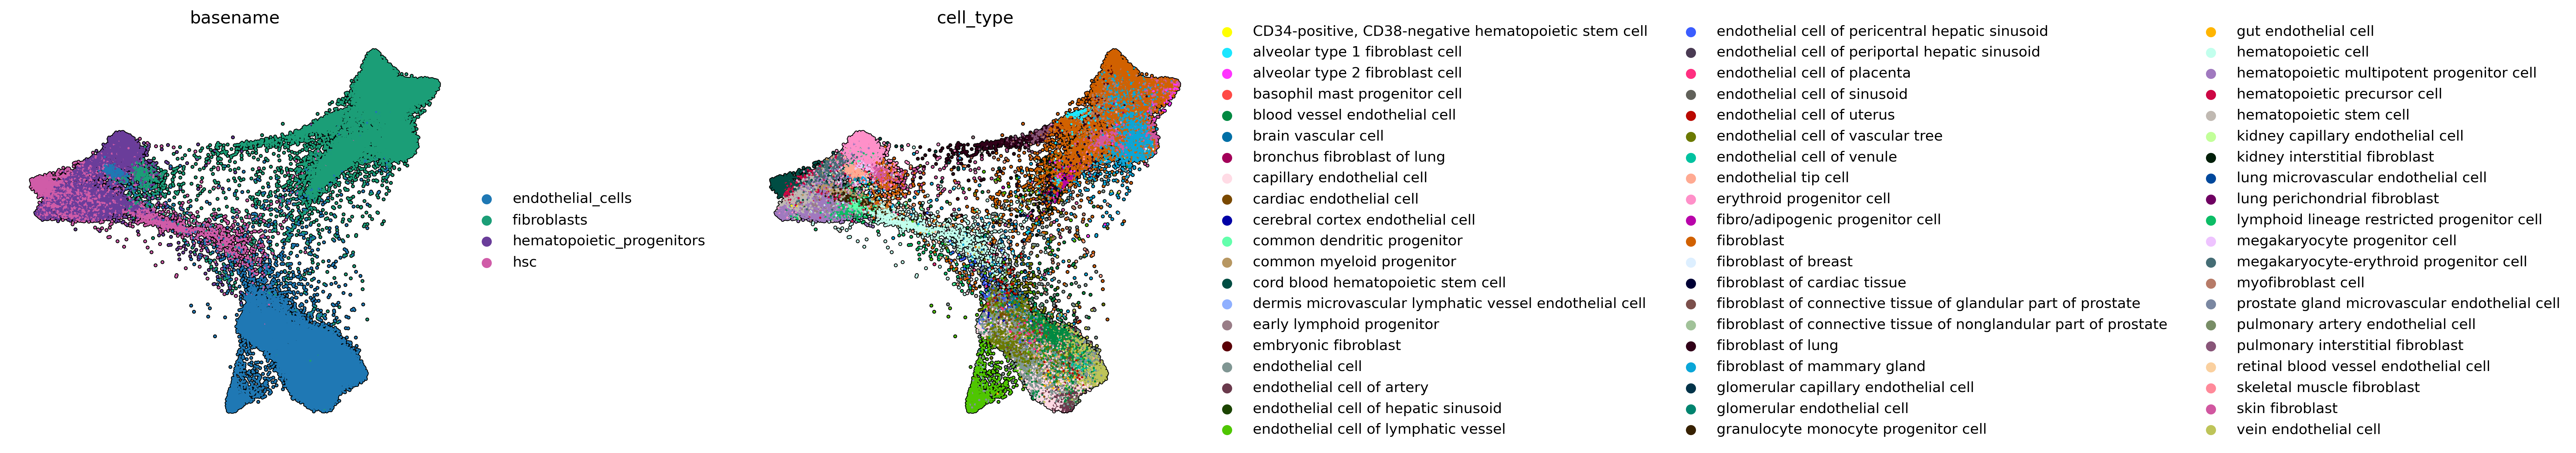

In [6]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 5

adata.obs['cell_type'] = adata.obs['cell_type'].astype(str)

sc.pl.draw_graph(
    adata, 
    color=["basename", "cell_type"],
    size=10,
    ncols=4,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

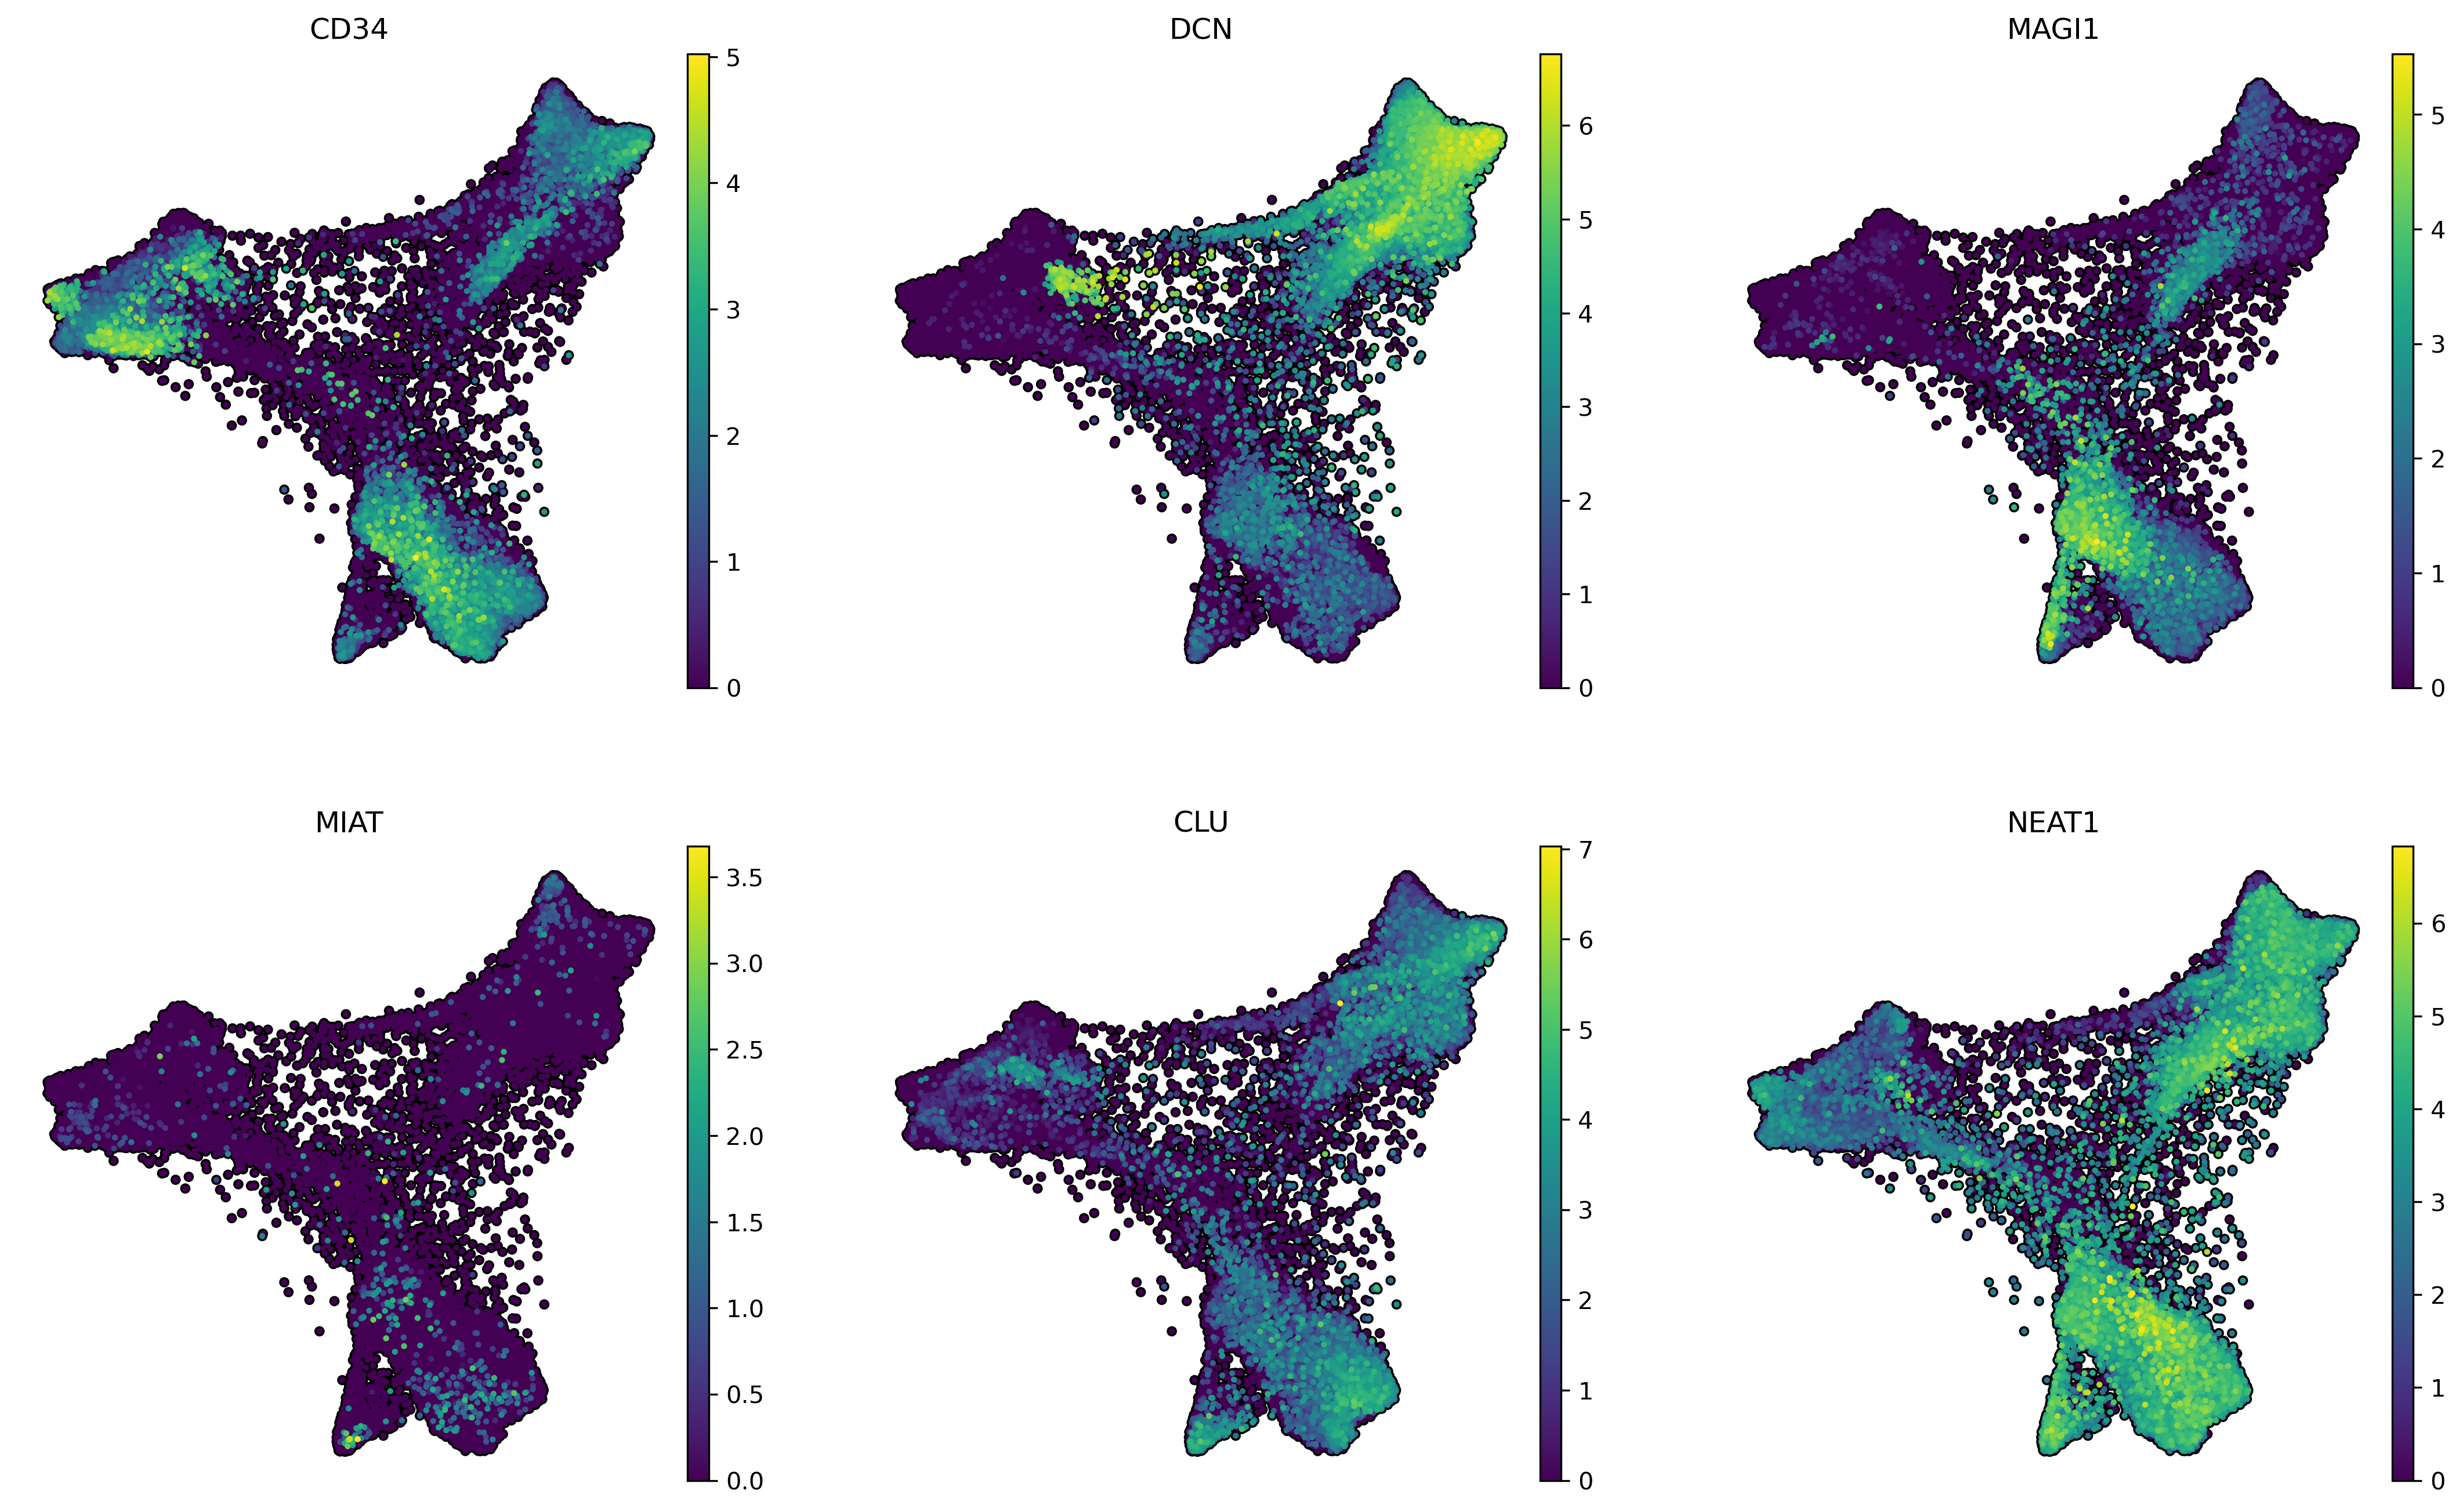

In [8]:
rsc.get.anndata_to_CPU(adata) # move to GPU

colors = [
    'CD34', 
    'DCN',
    'MAGI1', 
    'MIAT',
    'CLU',
    'NEAT1',
]

sc.pl.draw_graph(
    adata, 
    color=colors,
    size=25,
    ncols=3,
    alpha=1,
    colorbar_loc=None,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
)

In [ ]:
colors = [
   "KRT18", "MGP", "CLU", "SLC12A8", "FLNB", "LINC00842", "SLC44A1", "TPST2",
    "KCNMA1", "AHNAK2", "CENPT", "MAGI1", "ABTB2", "KRT19", "HIP1", "RBP1",
    "TSC22D1", "NEAT1", "HIPK2", "GSN"
]

sc.pl.draw_graph(
    adata, 
    color=colors,
    size=25,
    ncols=3,
    alpha=1,
    colorbar_loc=None,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
)

In [9]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
rsc.get.anndata_to_GPU(adata) # move to GPU

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 10, 10

palette = adata.uns['basename_palette']
print()

sc.pl.tsne(
    adata,
    color='basename',
    size=15,
    ncols=1,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=palette,
    frameon=False,
    title="",
)